<a href="https://colab.research.google.com/github/bentadev/tp-final-ds-grupo3/blob/main/TP_Airbnb_Grupo3_Madrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏙️📊TP FINAL: ANÁLISIS PREDICTIVO DE PRECIOS AIRBNB**

---

## **🎓Información Institucional**
**🏫Institución:** UOCRA – IFTS N° 33  
**🎓Carrera:** `Ciencia de datos e inteligencia artificial`  
**📚Materia:** `Ciencia de datos`  
**👩‍🏫Docente a cargo:** `Marisa Cánovas`  
**👥Modalidad:** Grupal 4 grupos × 5 a 6 integrantes  
**📅Fecha de entrega:** `20-6-26`  

---

## **👨‍💻 Integrantes del Grupo**

**📊Fase de Análisis (EDA)**
- `Priscila Chino`
- `Rosmery Ramirez`

**🧹Fase de Transformación**
- `Martin Bentancor`

**🤖Fase de Modelo de IA**
- `Maria Mamani`
- `Emmanuel Flores`:

---

## **🎯Objetivo del Trabajo**
Desarrollar un flujo completo de **Ciencia de Datos** aplicado al sector inmobiliario temporario. Cada grupo deberá **limpiar**, **explorar** y **modelar un dataset** real de **Airbnb** para **predecir** el precio por noche y comunicar hallazgos accionables para un inversor. Realizando:

- 🧹 Limpieza y preparación de datos
- 📊 Análisis exploratorio (EDA)
- 🤖 Modelado predictivo de precios por noche
- 📈 Evaluación de desempeño del modelo
- 🧠 Interpretación de variables relevantes

---

## **🌍Asignaciónd de Ciudades y Datasets**
Cada grupo trabaja con una **ciudad** distinta. La estructura de **columnas** es estandarizada, pero la dinámica de mercado, **outliers** y distribución de precios variarán.

| Grupo | Ciudad | País | Enlace de descarga directa |
|:---:|:---|:---|:---|
| **2** | **New York City** | 🇺 USA |https://insideairbnb.com/get-the-data/
| **3** | **Madrid** | 🇪🇸 España |https://insideairbnb.com/get-the-data/
| **4** | **Buenos Aires** | 🇦🇷 Argentina |https://insideairbnb.com/get-the-data/
  **5** | **Tokio** | Japón|https://insideairbnb.com/get-the-data/
https://insideairbnb.com/get-the-data/ y localizar la ciudad solicitada

---

## **📌Entregables**
1. **Notebook Jupyter (`.ipynb`)**: Código ejecutable, comentarios técnicos y celdas de Markdown explicativas.
2. **Presentación Oral (10-15 min)**: Síntesis del proceso, visualizaciones clave, métricas del modelo y conclusión de negocio.
3. **Defensa Técnica**: Cada integrante deberá responder preguntas sobre su sección del código.

---

## **✅Checklist de Trabajo (Requisitos mínimos)**
Marcar cada ítem completado dentro del notebook:

- [ ] Carga del dataset y exploración inicial
- [ ] Limpieza de la variable objetivo `price`: conversión a numérico y manejo de valores extremos.
- [ ] Tratamiento de datos faltantes y duplicados (documentar la decisión tomada).
- [ ] **Codificación de variables categóricas**: Transformar columnas de texto (ej: `room_type`, `neighbourhood`) a formato numérico compatible con el modelo.
- [ ] Selección de features y división Train/Test.
- [ ] Entrenamiento de un modelo de regresión y evaluación con métricas estándar (R², MAE/RMSE).
- [ ] Interpretación de coeficientes: ¿qué variables explican mejor el precio en esta ciudad?
- [ ] Visualizaciones claras y etiquetadas que respalden las conclusiones.

---

## **🏆Rúbrica de Evaluación (100 puntos)**

| Criterio | Descripción | Puntaje |
|----------|-------------|:-------:|
| **Proceso de Limpieza** | Manejo consistente de nulos, tipos de datos y outliers. Documentación clara de decisiones. | 25 |
| **Análisis Exploratorio** | Visualizaciones pertinentes, bien construidas y con interpretación contextual. | 25 |
| **Modelado y Métricas** | Pipeline correcto, evaluación en test, interpretación técnica de resultados. | 25 |
| **Defensa y Comunicación** | Claridad expositiva, dominio técnico individual, capacidad de justificar decisiones. | 25 |
| **TOTAL** | | **100** |

---

## **🛡️Política de Integridad Académica**
- Se permite consultar la documentación oficial de **Pandas**, **Scikit-Learn** y foros técnicos para resolver errores de sintaxis.
- **No se aceptará** código generado íntegramente por IA o copiado de compañeros de otro grupo. Durante la defensa oral se solicitará la explicación línea por línea de secciones claves.
- El objetivo es evaluar el **criterio técnico y la capacidad de resolución**, no la velocidad de obtención de un script funcional.
- Cualquier indicio de autoría no verificable derivará en la instancia de recuperación o reprobación según el reglamento institucional.

---

## **💡Consejo Pedagógico**
> *"En **Ciencia de Datos** aplicada, un **R²** alto no garantiza un buen análisis. Lo que diferencia un trabajo académico de un script automático es la capacidad de explicar **por qué** se tomó cada decisión de limpieza, **qué** limitaciones tiene el modelo y **cómo** se traduce eso al contexto real de la ciudad analizada."*

---

## **📬Entrega**
- **Plataforma:** `Moodle `
- **Nombre de archivo:** `TP_Airbnb_GrupoX_Ciudad.ipynb`
- **Fecha límite:** `20-6-26`




In [1]:
# Librerías para el análisis y transformación de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para el modelo de IA.

In [2]:
# Ruta Raw del dataset a traves del GitHub.
ruta_dataset = 'https://raw.githubusercontent.com/bentadev/tp-final-ds-grupo3/refs/heads/main/dataset_airbnb_madrid.csv'

# Carga del dataset.
dataset = pd.read_csv(ruta_dataset)

# Copia segura de trabajo.
df = dataset.copy()

In [3]:
# Diccionario con las traducciones exactas de las 17 columnas.
diccionario_traduccion = {
    "id": "id_alojamiento",
    "name": "nombre_alojamiento",
    "host_id": "id_anfitrion",
    "host_name": "nombre_anfitrion",
    "neighbourhood_group": "grupo_barrio",
    "neighbourhood": "barrio",
    "latitude": "latitud",
    "longitude": "longitud",
    "room_type": "tipo_habitacion",
    "price": "precio",
    "minimum_nights": "minimo_noches",
    "number_of_reviews": "cantidad_resenas",
    "last_review": "ultima_resena",
    "reviews_per_month": "resenas_por_mes",
    "calculated_host_listings_count": "cantidad_alojamientos_anfitrion",
    "availability_365": "disponibilidad_anual",
    "number_of_reviews_ltm": "resenas_ultimos_12_meses",
    "license": "licencia"
}

# Aplicmaos el cambio de forma permanente.
df.rename(columns=diccionario_traduccion, inplace=True)

# Vista de control para verificar los nuevos nombres en español.
print(df.columns.tolist())

['id_alojamiento', 'nombre_alojamiento', 'id_anfitrion', 'nombre_anfitrion', 'grupo_barrio', 'barrio', 'latitud', 'longitud', 'tipo_habitacion', 'precio', 'minimo_noches', 'cantidad_resenas', 'ultima_resena', 'resenas_por_mes', 'cantidad_alojamientos_anfitrion', 'disponibilidad_anual', 'resenas_ultimos_12_meses', 'licencia']


# **📊1. Análisis Exploratorio de Datos (EDA)**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_alojamiento                   25000 non-null  int64  
 1   nombre_alojamiento               25000 non-null  object 
 2   id_anfitrion                     25000 non-null  int64  
 3   nombre_anfitrion                 24903 non-null  object 
 4   grupo_barrio                     25000 non-null  object 
 5   barrio                           25000 non-null  object 
 6   latitud                          25000 non-null  float64
 7   longitud                         25000 non-null  float64
 8   tipo_habitacion                  25000 non-null  object 
 9   precio                           18953 non-null  float64
 10  minimo_noches                    25000 non-null  int64  
 11  cantidad_resenas                 25000 non-null  int64  
 12  ultima_resena     

## Fase 1: Calidad de Datos y Diagnóstico de Faltantes


### 1.1. Análisis del Target (price):

* Calcular estadísticas clave: media, mediana, mínimo, máximo y desvío estándar.
* Gráfico recomendado: Histograma y Boxplot del precio para ver la forma de la distribución (seguramente tendrá una asimetría hacia la derecha por los precios altos).


Estadísticas descriptivas para 'precio':
count    18953.000000
mean       156.691447
std        492.255350
min          8.000000
25%         70.000000
50%        110.000000
75%        164.000000
max      25654.000000
Name: precio, dtype: float64


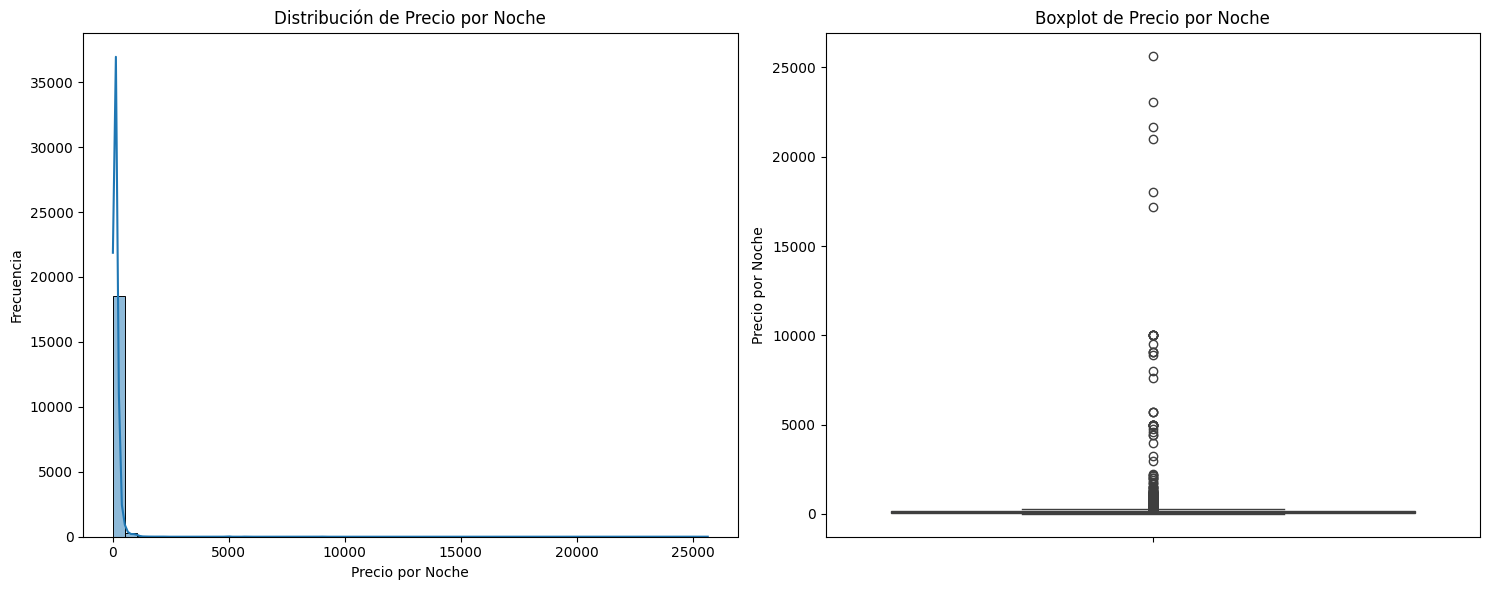

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular estadísticas clave para la columna 'Precio_Noche'
print("\nEstadísticas descriptivas para 'precio':")
print(df['precio'].describe())

# 2. Visualizar la distribución de 'Precio_Noche'
plt.figure(figsize=(15, 6))

# Histograma
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df['precio'].dropna(), bins=50, kde=True)
plt.title('Distribución de Precio por Noche')
plt.xlabel('Precio por Noche')
plt.ylabel('Frecuencia')

# Boxplot
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(y=df['precio'].dropna())
plt.title('Boxplot de Precio por Noche')
plt.ylabel('Precio por Noche')

plt.tight_layout()
plt.show()

### Duplicados en la columna 'precio'

In [9]:
# Identificar y mostrar las filas donde el 'Precio_Noche' está duplicado
duplicados_precio = df[df['precio'].duplicated(keep=False)].sort_values(by='precio')

print(f"\n--- Filas con 'precio' duplicado ({len(duplicados_precio)} filas) ---")
display(duplicados_precio.head(10)) # Mostrar las primeras 10 filas para una vista previa
print("-" * 70)


--- Filas con 'precio' duplicado (24802 filas) ---


,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
23452,1437001338074317170,Visita y descansa en Madrid,407104327,Raquel,Ciudad Lineal,Pueblo Nuevo,40.431827,-3.643968,Private room,8.0,2,1,2025-06-28,0.38,2,27,1,NaN
15012,1052771142273730407,Excelente habitación,209525802,Juan David,Arganzuela,Chopera,40.394836,-3.699599,Private room,8.0,1,0,NaN,NaN,1,85,0,NaN
15759,1100744628408531352,"Piso en Salamanca, centro",28810090,Karla,Salamanca,Guindalera,40.436240,-3.672420,Private room,9.0,5,1,2024-12-02,0.10,1,0,1,NaN
14847,1044295365361757805,Bello dpto en manzanares,475355535,Manuel,Carabanchel,Comillas,40.395473,-3.708662,Private room,9.0,1,1,2024-01-01,0.05,2,128,0,NaN
22147,1391346173939572139,Un espacio agradable y cómodo.,687944221,Wendis Dayanis,Hortaleza,Apostol Santiago,40.481185,-3.658422,Private room,9.0,1,0,NaN,NaN,1,9,0,NaN
23647,1443448776185683992,Apart. Duplex Puerta de Toledo,446760611,Raul,Centro,Embajadores,40.405770,-3.706440,Entire home/apt,9.0,7,0,NaN,NaN,36,350,0,NaN
14838,1043392917218974369,Bello alojamiento en manzanares,475355535,Manuel,Carabanchel,Comillas,40.394920,-3.708670,Private room,9.0,1,0,NaN,NaN,2,99,0,NaN
12355,892491869203638852,Bed in Cute & Shared Room near Center,514431098,Javier,Carabanchel,Vista Alegre,40.378989,-3.749394,Shared room,15.0,3,41,2025-09-04,1.47,5,66,11,NaN
15748,1099992890034269428,Hermosa habitación cerca al aeropuerto,564097287,Carlos,Puente de Vallecas,San Diego,40.385762,-3.669942,Private room,15.0,1,1,2024-06-10,0.06,1,184,0,NaN
7768,49898995,Habitación bonita Embajadores metro Tirso Molina,402370216,W Rodrigo,Centro,Embajadores,40.406520,-3.702330,Private room,15.0,10,22,2024-10-31,0.43,6,176,2,NaN


----------------------------------------------------------------------


In [10]:
# Para ver la cantidad de valores únicos de precio que están duplicados
print("\n--- Conteo de 'precio' duplicados ---")
conteo_precios_duplicados = duplicados_precio['precio'].value_counts()
display(conteo_precios_duplicados.head(10)) # Mostrar los 10 precios más duplicados
print("-" * 70)


--- Conteo de 'precio' duplicados ---


,count
precio,
90.0,216
80.0,174
85.0,164
100.0,164
60.0,161
110.0,158
105.0,157
40.0,154
65.0,150


----------------------------------------------------------------------


### Identificación de Outliers en 'Precio_Noche' (Método IQR)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la columna 'precio' sin valores nulos
precio_clean = df['precio'].dropna()

# Calcular los cuartiles (Q1 y Q3) y el rango intercuartílico (IQR)
Q1 = precio_clean.quantile(0.25)
Q3 = precio_clean.quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para identificar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\n--- Análisis de Outliers para 'precio' ---")
print(f"Primer Cuartil (Q1): {Q1:.2f}")
print(f"Tercer Cuartil (Q3): {Q3:.2f}")
print(f"Rango Intercuartílico (IQR): {IQR:.2f}")
print(f"Límite Inferior para Outliers: {limite_inferior:.2f}")
print(f"Límite Superior para Outliers: {limite_superior:.2f}")

# Identificar outliers
outliers_inferiores = precio_clean[precio_clean < limite_inferior]
outliers_superiores = precio_clean[precio_clean > limite_superior]

print(f"\nCantidad de outliers inferiores: {len(outliers_inferiores)}")
print(f"Cantidad de outliers superiores: {len(outliers_superiores)}")

print("\n--- Ejemplos de Outliers Superiores (primeros 10) ---")
display(outliers_superiores.sort_values(ascending=False).head(10))
print("-" * 60)



--- Análisis de Outliers para 'precio' ---
Primer Cuartil (Q1): 70.00
Tercer Cuartil (Q3): 164.00
Rango Intercuartílico (IQR): 94.00
Límite Inferior para Outliers: -71.00
Límite Superior para Outliers: 305.00

Cantidad de outliers inferiores: 0
Cantidad de outliers superiores: 1183

--- Ejemplos de Outliers Superiores (primeros 10) ---


,precio
579,25654.0
8397,23085.0
4976,21685.0
7174,21000.0
13321,18000.0
2260,17159.0
19008,10000.0
12787,9999.0
12791,9999.0
12797,9999.0


------------------------------------------------------------


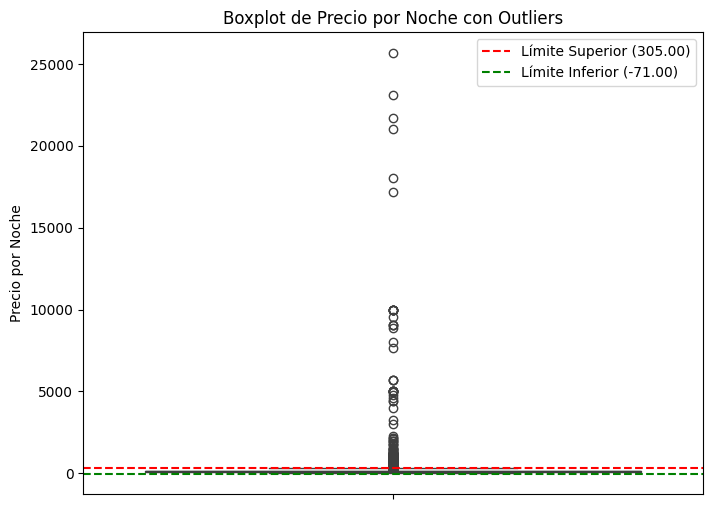

In [ ]:
# Visualización de Outliers con Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Precio_Noche'].dropna())
plt.title('Boxplot de Precio por Noche con Outliers')
plt.ylabel('Precio por Noche')

# Opcional: Añadir líneas para los límites de outlier en el boxplot
# Nota: Estas líneas pueden no ser visibles si no hay outliers más allá de los bigotes
plt.axhline(y=limite_superior, color='r', linestyle='--', label=f'Límite Superior ({limite_superior:.2f})')
plt.axhline(y=limite_inferior, color='g', linestyle='--', label=f'Límite Inferior ({limite_inferior:.2f})')
plt.legend()
plt.show()

## Análisis de Percentiles y Distribución Acumulada para 'Precio_Noche'

In [12]:
# Filtrar valores nulos de Precio_Noche para el análisis
precio_noche_filtrado = df['precio'].dropna()

# Calcular percentiles clave
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.0]
valores_percentiles = precio_noche_filtrado.quantile(percentiles)

print("--- Percentiles de precio ---")
for p, val in zip(percentiles, valores_percentiles):
    print(f"P{p*100:.1f}: {val:.2f}")
print("-" * 30)

--- Percentiles de precio ---
P1.0: 21.00
P5.0: 31.00
P10.0: 41.00
P25.0: 70.00
P50.0: 110.00
P75.0: 164.00
P90.0: 249.00
P95.0: 343.00
P99.0: 793.36
P99.5: 1000.00
P99.9: 7641.10
P100.0: 25654.00
------------------------------


#### Interpretación de los Percentiles

*   **Percentiles:** Nos permiten entender la dispersión de los datos. Por ejemplo, el P50 (mediana) nos dice que el 50% de las propiedades tienen un precio igual o inferior a ese valor. Los percentiles más altos (P90, P95, P99) confirman la presencia de precios muy elevados, lo que ya habíamos identificado como outliers.

In [13]:
# Filtrar el DataFrame para mostrar filas donde 'Precio_Noche' es mayor a 150
filas_precio_alto = df[df['precio'] > 5000]
# Mostrar las primeras 20 filas completas de este subconjunto
display(filas_precio_alto.head(8))

,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
306,2294171,Buhardilla en el Madrid de los Austrias,11719928,Mariano,Centro,Sol,40.417377,-3.706745,Entire home/apt,9515.0,4,8,2024-12-29,0.31,3,0,1,NaN
579,5361601,♡Comfort 2 Bedrooms/2 Bathrooms apt. WiFi & AC,3983613,Raul,Centro,Sol,40.418460,-3.707240,Entire home/apt,25654.0,3,149,2025-09-09,1.19,2,28,13,ESFCNT0000280910006330040000000000000000000000...
2260,18816591,PUERTA DEL ANGEL,1408525,Mad4Rent,Latina,Puerta del Angel,40.409160,-3.732560,Entire home/apt,17159.0,3,63,2025-02-20,0.62,75,0,7,00
4976,34570478,Apartamento,260848309,Elo,Centro,Sol,40.417356,-3.701313,Entire home/apt,21685.0,2,117,2023-06-25,1.53,1,137,0,NaN
6985,43828290,Madrid,17011402,Nicolas,Centro,Palacio,40.421700,-3.710090,Entire home/apt,5706.0,4,4,2021-12-07,0.07,10,243,0,NaN
7063,44265422,Madrid,17011402,Nicolas,Centro,Universidad,40.425070,-3.711350,Entire home/apt,5706.0,5,6,2021-10-21,0.11,10,243,0,NaN
7072,44305807,Alquilo Apartamento Centro,290977158,Maria,Arganzuela,Imperial,40.406730,-3.717570,Entire home/apt,7623.0,40,0,NaN,NaN,1,270,0,NaN
7174,45249073,Captivating Apartment in Madrid near El Retiro...,362191258,Juanita - BELVILLA,Puente de Vallecas,Palomeras Bajas,40.391400,-3.664250,Entire home/apt,21000.0,1,0,NaN,NaN,1,365,0,VT-11002


## **🧹2. Transformación y Preparación de Datos**

## **🤖3. Modelo Predictivo de Machine Learning**

## **🧪4. Evaluación del Modelo y Conclusiones**